# The AMAT model in NESTML

This notebook guides you through writing the Augmented Multi-adaptive Threshold (AMAT) model in NESTML, and runs basic simulations and characterisations of the model. This script validates the numerical results, performs a parameter space exploration, and then use the AMAT model in a balanced network.

Prerequisites
-------------

You need to have a working NEST Simulator and NESTML installation, see [Installing NESTML](https://nestml.readthedocs.io/en/latest/installation.html).

You need to be able to run NESTML to generate and build model code. NESTML can be used from the command line, and via a Python API. The latter will be used in this notebook. See [Running NESTML](https://nestml.readthedocs.io/en/latest/running.html).

In [1]:
%matplotlib inline

from dataclasses import dataclass, replace
from pathlib import Path
from typing import Any, Sequence
import time

import matplotlib.pyplot as plt
import nest
import numpy as np
from scipy import stats

import pynestml
from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils

print(f"NEST version: {nest.__version__}")
print(f"NESTML version: {pynestml.__version__}")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Feb 25 2026 18:10:15

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

NEST version: 3.9.0
NESTML version: 8.3.0-rc3-post-dev


## Introduction to the AMAT model  

The AMAT model adds a voltage-dependent component to the adaptive threshold of the `mat2_psc_exp` neuron.

### Membrane Potential
The subthreshold membrane potential follows leaky integration:
$$ \frac{dV}{dt} = -\frac{V-E_L}{\tau_m} + \frac{I(t)}{C_m} $$
Where $V$ is membrane potential, $E_L$ is resting potential, $\tau_m$ is the membrane time constant, and $I(t)$ is total input current.

### Spike Condition
A spike occurs when the membrane potential crosses the adaptive threshold $\theta(t)$:
$$ V(t) \geq \theta(t) $$
$$ \theta(t) = \omega + \theta_{\alpha_1}(t) + \theta_{\alpha_2}(t) + \theta_V(t) $$

### Spike-History Threshold
The two spike-history components obey:
$$ \frac{d\theta_{\alpha_i}}{dt} = -\frac{\theta_{\alpha_i}}{\tau_i} + \alpha_i \sum_k \delta(t-t_k), \qquad i\in\{1,2\} $$
Here, $\alpha_i$ dictates the threshold increase following a spike, and $\tau_i$ is its decay time constant.

### Voltage-Dependent Threshold
The AMAT extension adds a dynamic voltage-dependent threshold component:
$$ \theta_V(t) = \beta \int_0^\infty K(s)\, \frac{dV}{dt}(t-s)\,ds $$
Using the alpha-function kernel:
$$ K(s)=s\,e^{-s/\tau_V} $$

**Reference:** Yamauchi, S. et al. (2011). *Elemental Spiking Neuron Model for Reproducing Diverse Firing Patterns and Predicting Precise Firing Times* Front. Comput. Neurosci. 
[https://www.frontiersin.org/journals/computational-neuroscience/articles/10.3389/fncom.2011.00042/full]

## Formulating the model in NESTML

See the file ``amat_neuron.nestml`` in the neuron models directory (https://github.com/nest/nestml/tree/main/models/neurons/amat_neuron.nestml)

In [2]:
nest.ResetKernel() # rest nest kernel 

# create and specify module and model variable names to avoid stale build
nestml_module, nestml_neuron_model = NESTCodeGeneratorUtils.generate_code_for(
    "amat_neuron.nestml",
    logging_level="WARNING")

nest.Install(nestml_module)

assert nestml_neuron_model in nest.node_models
print(f"Loaded fresh NESTML module:{nestml_module}")
print(f"Generated neuron model:{nestml_neuron_model}")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Feb 25 2026 18:10:15

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



[ODE-toolbox] WARNING:Under certain conditions, the propagator matrix is singular (contains infinities).
[ODE-toolbox] WARNING:List of all conditions that result in a division by zero:
[ODE-toolbox] WARNING:	tau_v = tau_syn_inh
[ODE-toolbox] WARNING:	tau_m = tau_syn_inh
[ODE-toolbox] WARNING:	tau_m = tau_syn_exc
[ODE-toolbox] WARNING:	tau_v = tau_syn_exc
[ODE-toolbox] WARNING:	tau_v = tau_m
[ODE-toolbox] WARNING:	__h = 0
[ODE-toolbox] WARNING:Not preserving expression for variable "V_th_alpha_1" as it is solved by propagator solver
[ODE-toolbox] WARNING:Not preserving expression for variable "V_th_alpha_2" as it is solved by propagator solver
[ODE-toolbox] WARNING:Not preserving expression for variable "V_m" as it is solved by propagator solver
[ODE-toolbox] WARNING:Not preserving expression for variable "V_th_v_aux" as it is solved by propagator solver
[ODE-toolbox] WARNING:Not preserving expression for variable "V_th_v" as it is solved by propagator solver
[ODE-toolbox] WARNING:Not p

Loaded fresh NESTML module:nestml_88354016320c4680bb232cf9c29e7551_module
Sep 15 10:21:42 Install [Info]: 
    loaded module nestml_88354016320c4680bb232cf9c29e7551_modu
Generated neuron model:amat_neuron_nestml
le


## Formulating the AMAT NEST model 

The file ``amat2_psc_exp`` can be found in the model directory of nestml directory 
(https://github.com/nest/nest-simulator/tree/main/models/amat2_psc_exp.cpp)

This is a handtuned C++ NEST reference model developed in which the NESTML AMAT model will be validated against. 

**Reference:** Heiberg et al.., (2018), *Firing-rate models for neurons with a broad repertoire of spiking behaviors* Front. Comput. Neurosci. 
[https://link.springer.com/article/10.1007/s10827-018-0693-9]


In [3]:
nest_model_name = "amat2_psc_exp"

if nest_model_name not in nest.node_models:
    raise RuntimeError("This NEST installation does not provide the native amat2_psc_exp model.")
else: 
    print(f"Native NEST model available: {nest_model_name}")

Native NEST model available: amat2_psc_exp


## Shared Parameters 

Both implementations are configured through the public PyNEST API using the same physical parameter values. In particular, `omega` is supplied as the **absolute resting spike threshold** in both models; with \(E_L=-70\) mV and \(omega=-65\) mV, the resting threshold therefore lies 5 mV above the leak potential.

The helper below handles only the parameter names that genuinely differ between native NEST and the generated NESTML model (for example `t_ref` versus `refr_T`, and the synaptic time-constant names). This keeps all numerical experiments on one shared configuration.


In [4]:
@dataclass(frozen=True) # pass AMATConfig into both nestml and nest configs 
class AMATConfig:
    
    # Standard validation stimulus
    pulse_times_ms: tuple[float, ...] = (10.0, 30.0, 210.0, 270.0)
    pulse_amplitude_pa: float = 1000.0
    pulse_width_ms: float = 1.0
    simulation_time_ms: float = 400.0

    # Constant bias current. 
    I_e_pa: float = 0.0
    
    # Pulse-pair sweep settings. A lower pulse amplitude keeps most responses subthreshold for visualisation 
    first_pulse_ms: float = 50.0
    sweep_pulse_amplitude_pa: float = 450.0
    response_window_ms: float = 50.0

    # Membrane and threshold parameters
    tau_m_ms: float = 10.0
    C_m_pf: float = 200.0
    t_ref_ms: float = 2.0
    E_L_mv: float = -70.0
    resting_threshold_mv: float = -65.0 # referred to as omega 

    # Synaptic and spike-history adaptation time constants
    tau_syn_ex_ms: float = 1.0
    tau_syn_in_ms: float = 3.0
    tau_1_ms: float = 10.0
    tau_2_ms: float = 200.0

    alpha_1_mv: float = 10.0 # Short-term adaptation strength
    alpha_2_mv: float = 0.0 # Long-term adaptation strength 

    # Dimensionless AMAT voltage-dependent threshold parameters:
    # gamma = tau_v / tau_m and B = beta * tau_m
    gamma: float = 1.25
    B: float = 1.5

    # Balanced-network parameters
    g: float = 4.0
    eta: float = 1.0
    epsilon: float = 0.1
    balanced_simtime: float = 1000.0
    delay: float = 1.0
    order: int = 250 # 4x exc 1x inh 
    J_ex: float = 0.15 # target peak excitatory PSP in mV


    # Simulation resolution
    resolution: float = 0.1

## Helper functions 

- `run_amat_model`
- `model_parameters`
- `ensure_model_available`
- `reconstruct_threshold_component`

In [5]:
def model_parameters(model_name, config):
    """Translate one shared AMAT parameter set to the selected model API."""

    params = {  # shared amat params across NESTML and NEST 
        "tau_m": config.tau_m_ms,
        "C_m": config.C_m_pf,
        "E_L": config.E_L_mv,
        "tau_1": config.tau_1_ms,
        "tau_2": config.tau_2_ms,
        "alpha_1": config.alpha_1_mv,
        "alpha_2": config.alpha_2_mv,
        "tau_v": config.gamma * config.tau_m_ms,   # gamma = tau_v / tau_m and B = beta * tau_m
        "beta": config.B / config.tau_m_ms,
        "omega": config.resting_threshold_mv,
        "I_e": config.I_e_pa,
    }

    if model_name == "amat2_psc_exp":  # NEST 
        params.update({
            "t_ref": config.t_ref_ms,  # avoiding misnaming mismatches 
            "tau_syn_ex": config.tau_syn_ex_ms,
            "tau_syn_in": config.tau_syn_in_ms})
    elif model_name == nestml_neuron_model: # NESTML 
        params.update({
            "refr_T": config.t_ref_ms,
            "tau_syn_exc": config.tau_syn_ex_ms,
            "tau_syn_inh": config.tau_syn_in_ms})
    else:
        raise ValueError(f"Unsupported AMAT model: {model_name}")

    # Pass only parameters exposed by the selected model.
    defaults = nest.GetDefaults(model_name)
    return {name: value for name, value in params.items() if name in defaults}


def ensure_model_available(model_name):
    """Helper function to load the generated module if ResetKernel removed its registered model."""
    if model_name in nest.node_models:
        return

    if model_name == nestml_neuron_model:
        nest.Install(nestml_module)

    if model_name not in nest.node_models:
        raise RuntimeError(f"Model is not available in the current NEST kernel: {model_name}")


def run_amat_model(model_name, config):
    """Run one AMAT simulation and return traces in a common format."""

    nest.ResetKernel() # initialise the nest kernel 
    nest.SetKernelStatus({"resolution": config.resolution})
    nest.set_verbosity("M_ERROR")
    ensure_model_available(model_name)

    params = model_parameters(model_name, config) # pulling out the correct model parameters for model 
    neuron = nest.Create(model_name, params=params) # build AMAT model 

    amplitude_times = []
    amplitude_values = []
    for onset in config.pulse_times_ms:
        amplitude_times.extend([onset, onset + config.pulse_width_ms]) # pulse configuration
        amplitude_values.extend([config.pulse_amplitude_pa, 0.0])

    current = nest.Create("step_current_generator", params={"amplitude_times": amplitude_times, "amplitude_values": amplitude_values})

    # recording the neuron from specified params  
    defaults = nest.GetDefaults(model_name)
    requested = ["V_m", "V_th", "V_th_alpha_1", "V_th_alpha_2", "V_th_v", "V_th_v_aux", "I_syn"]
    recordables = [name for name in requested if name in defaults["recordables"]]

    # configure the multimeter 
    multimeter = nest.Create("multimeter", params={"interval": config.resolution, "record_from": recordables})
    
    spikes = nest.Create("spike_recorder")  # initialise the spike recorder 
    nest.Connect(current, neuron) # connecting neuron to recording devices 
    nest.Connect(multimeter, neuron)
    nest.Connect(neuron, spikes)

    nest.Simulate(config.simulation_time_ms) # simulation 
    events = multimeter.get("events") 
    spike_events = spikes.get("events")
    times = np.asarray(events["times"], dtype=float) # collect event spikes 

    # Reconstruct the total applied current for plotting
    input_current = np.full_like(times, config.I_e_pa, dtype=float)
    for onset in config.pulse_times_ms:
        active = ((times >= onset) & (times < onset + config.pulse_width_ms))
        input_current[active] += config.pulse_amplitude_pa

    # define result dict to return  
    result = {"times": times, "input_current": input_current, "spike_times": np.asarray(spike_events["times"], dtype=float)}

    for name in recordables:
        result[name] = np.asarray(events[name], dtype=float)

    result["distance"] = result["V_m"] - result["V_th"] # distance from membrane potential to threshold 
    return result

def reconstruct_threshold_component(times, spike_times, alpha, tau):
    """Reconstruct one spike-history threshold component for NEST."""
    
    component = np.zeros_like(times)
    
    for spike_time in spike_times:
        after_spike = times > spike_time   # Apply the jump on the timestep after the spike, matching grid execution.
        component[after_spike] += alpha * np.exp(-(times[after_spike] - spike_time) / tau)

    return component


# Comparison between AMAT NEST and NESTML 

Both AMAT models now receive the same current wave forms and physical parameters. We can now overlay and compare their activities across two injected pulses at 10.0, 30.0, 210.0 and 270.0 ms. 


Sep 15 10:28:19 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.1 ms.
[INFO] Trace comparison
V_m             MAE=2.46321e-14  RMSE=3.18623e-14  max|Δ|=9.9476e-14
V_th            MAE=2.22759e-12  RMSE=4.21552e-12  max|Δ|=2.24958e-11
V_th_v          MAE=2.2276e-12  RMSE=4.21556e-12  max|Δ|=2.2497e-11
[INFO] Detected spike times
NEST  : []
NESTML: []


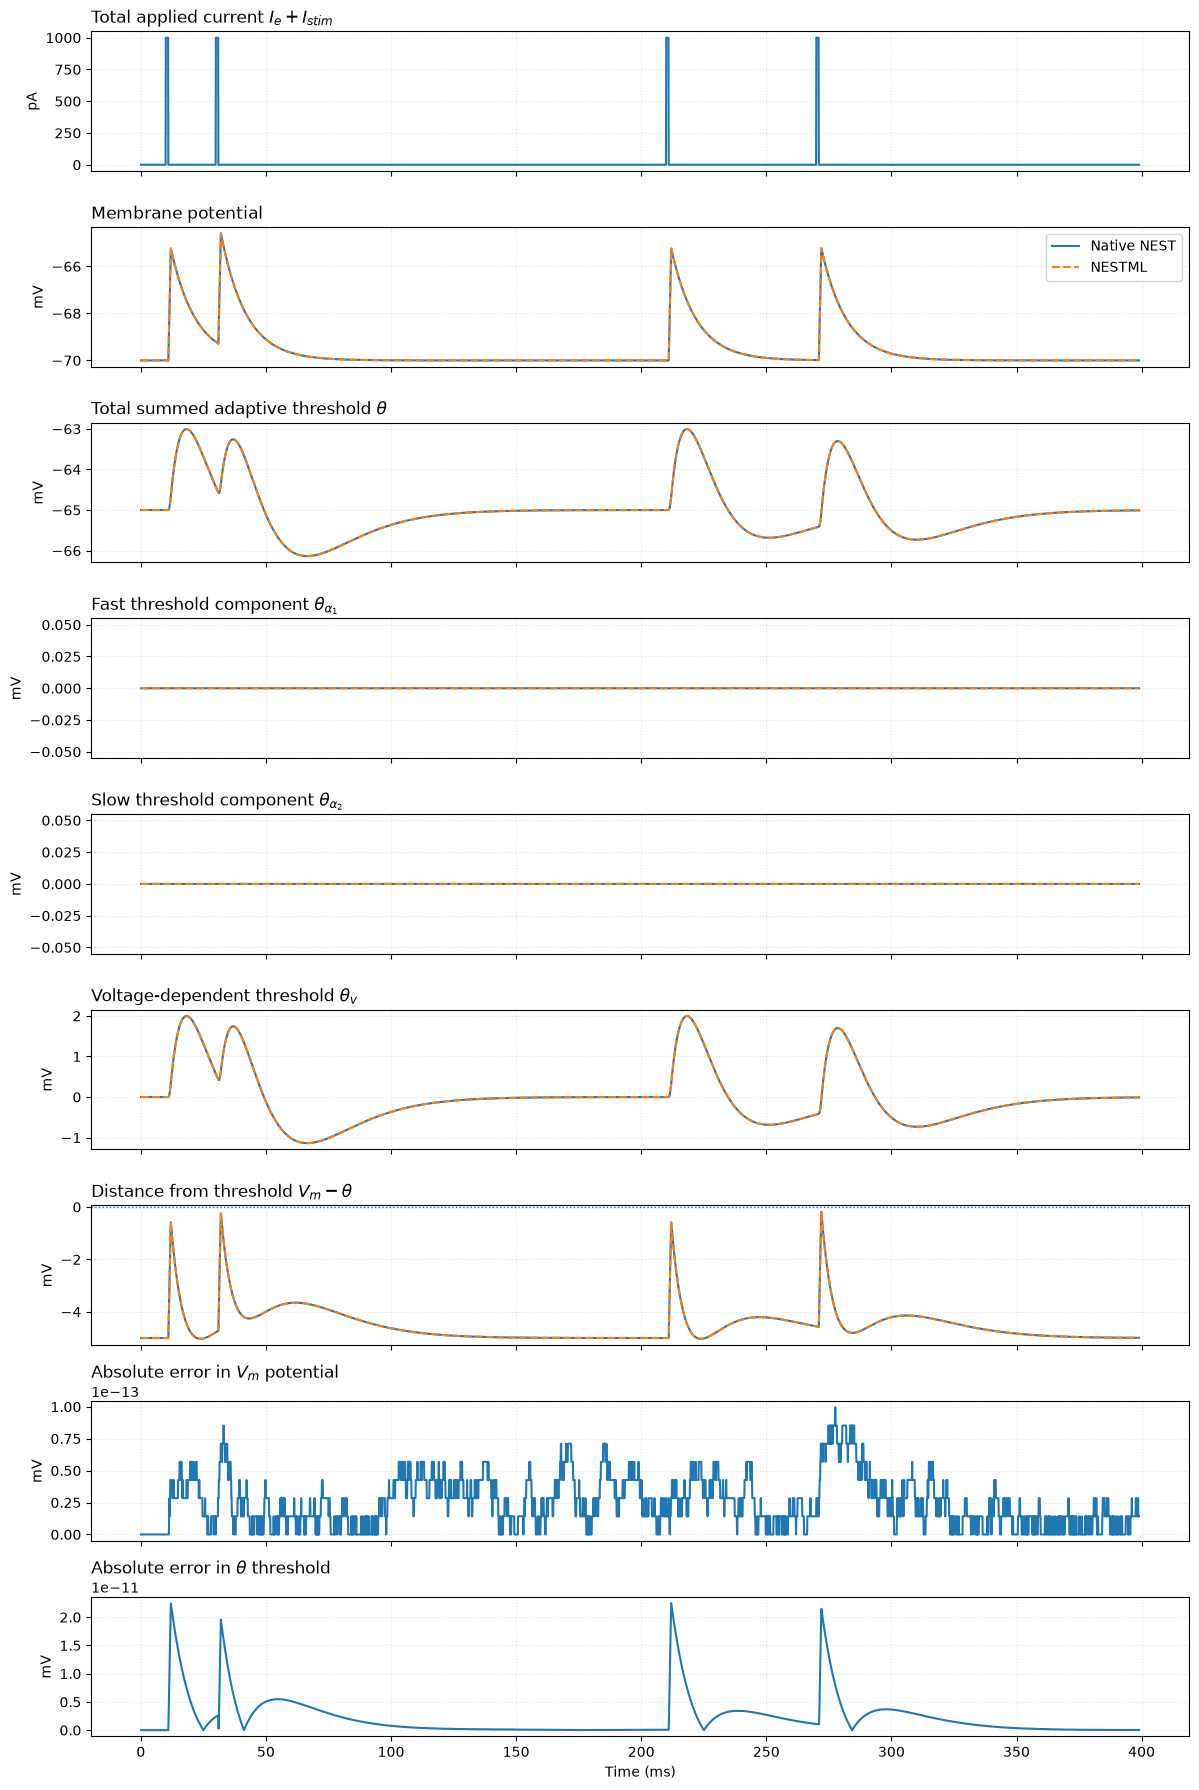

In [6]:
config = AMATConfig() # initalise config from params 

generated = run_amat_model(nestml_neuron_model, config) # NESTML 
native = run_amat_model(nest_model_name, config) # NEST 

# Reconstructing alpha_1 and alpha_2 for NEST, as it is not in the available recordables. 
native["V_th_alpha_1"] = reconstruct_threshold_component(native["times"], native["spike_times"], config.alpha_1_mv, config.tau_1_ms)
native["V_th_alpha_2"] = reconstruct_threshold_component(native["times"], native["spike_times"], config.alpha_2_mv, config.tau_2_ms,)

print("[INFO] Trace comparison")
for name in ("V_m", "V_th", "V_th_v"):
    error = generated[name] - native[name]

    print(f"{name:15s} "  # Info error debug
        f"MAE={np.mean(np.abs(error)):.6g}  "  # Mean absolute error (avg error across) 
        f"RMSE={np.sqrt(np.mean(error**2)):.6g}  " # root squared error across sim (penalising large errors)   
        f"max|Δ|={np.max(np.abs(error)):.6g}" # max error recorded  
    )    

print("[INFO] Detected spike times") # debugging statements, ensuring spike times are the same 
print("NEST  :", native["spike_times"])
print("NESTML:", generated["spike_times"])

# Plot comparison
fig, axes = plt.subplots(9, 1, figsize=(12, 18), sharex=True)

# Injected current
axes[0].plot(native["times"], native["input_current"])
axes[0].set_ylabel("pA")
axes[0].set_title(r"Total applied current $I_e + I_{stim}$", loc="left")

# Membrane potential
axes[1].plot(native["times"], native["V_m"], label="Native NEST")
axes[1].plot(generated["times"], generated["V_m"], "--", label="NESTML")
axes[1].set_ylabel("mV")
axes[1].set_title("Membrane potential", loc="left")
axes[1].legend()

# Total adaptive threshold
axes[2].plot(native["times"], native["V_th"], label="Native NEST")
axes[2].plot(generated["times"], generated["V_th"], "--", label="NESTML")
axes[2].set_ylabel("mV")
axes[2].set_title(r"Total summed adaptive threshold $\theta$", loc="left")

# Fast spike-history threshold
axes[3].plot(native["times"], native["V_th_alpha_1"], label="Native NEST")
axes[3].plot(generated["times"], generated["V_th_alpha_1"], "--", label="NESTML")
axes[3].set_ylabel("mV")
axes[3].set_title(r"Fast threshold component $\theta_{\alpha_1}$", loc="left")

# Slow spike-history threshold
axes[4].plot(native["times"], native["V_th_alpha_2"], label="Native NEST")
axes[4].plot(generated["times"], generated["V_th_alpha_2"], "--", label="NESTML")
axes[4].set_ylabel("mV")
axes[4].set_title(r"Slow threshold component $\theta_{\alpha_2}$", loc="left")


# Voltage-dependent threshold
axes[5].plot(native["times"], native["V_th_v"], label="Native NEST")
axes[5].plot(generated["times"], generated["V_th_v"], "--", label="NESTML")
axes[5].set_ylabel("mV")
axes[5].set_title(r"Voltage-dependent threshold $\theta_v$", loc="left")

# Distance from threshold
axes[6].plot(native["times"], native["distance"], label="Native NEST")
axes[6].plot(generated["times"], generated["distance"], "--", label="NESTML")
axes[6].axhline(0.0, linestyle=":", linewidth=1)
axes[6].set_ylabel("mV")
axes[6].set_title(r"Distance from threshold $V_m-\theta$", loc="left")

# Membrane-potential error
axes[7].plot(
    native["times"],
    np.abs(generated["V_m"] - native["V_m"]),
)
axes[7].set_ylabel("mV")
axes[7].set_title(r"Absolute error in $V_m$ potential", loc="left")

# Threshold error
axes[8].plot(
    native["times"],
    np.abs(generated["V_th"] - native["V_th"]),
)
axes[8].set_ylabel("mV")
axes[8].set_xlabel("Time (ms)")
axes[8].set_title(r"Absolute error in $\theta$ threshold", loc="left")


# Mark NEST spike times across all model-dynamics panels
for spike_time in native["spike_times"]:
    for ax in axes[:7]:
        ax.axvline(
            spike_time,
            color="red",
            linestyle=":",
            linewidth=1.0,
            alpha=0.7,
        )


for ax in axes:
    ax.grid(True, linestyle=":", alpha=0.35)

plt.tight_layout()
plt.show()

**Discussion.** The NESTML traces closely overlap the native `amat2_psc_exp` reference for membrane potential, adaptive-threshold dynamics, and spike timing (both 271.88ms; also represented as red dotted line on the plot). The small residual errors, on the bottom two panels, display small exponential differences in numerical implementations. 

## Resonator versus Integrator Dynamics in the AMAT Model

An **integrator** responds most strongly when inputs arrive close together, because successive inputs can accumulate before the earlier response has decayed. A **resonator** instead has a preferred range of inter-pulse intervals, so the response depends not only on input strength but also on input timing. This section investigates and validates the characteristics of resonators versus integrators using the AMAT NESTML model. 

These firing behaviours are depicted in the figure A1

<img src="images/integrator_resonator.png" width="1050" height="600">

**Reference:** Yamauchi, S. et al. (2011). *Elemental Spiking Neuron Model for Reproducing Diverse Firing Patterns and Predicting Precise Firing Times* Front. Comput. Neurosci. 
[https://www.frontiersin.org/journals/computational-neuroscience/articles/10.3389/fncom.2011.00042/full]

For each condition, two identical current pulses are delivered. The first pulse occurs at 50 ms and the second at \(50+\Delta\) ms; we then measure the largest post-pulse value of \(V_m-\theta\) and record whether a spike occurred. For these tuning curves the pulse amplitude is deliberately reduced to **450 pA**. Keeping most responses below threshold makes the effect of `B` and `gamma` easier to interpret. 

In [7]:
def delta_sweep(
    model_name: str,
    base_config: Any,
    deltas_ms: Sequence[float],
    sweep_type: str = "baseline") -> list:
    
    """Run a pulse-pair sweep for baseline, gamma, or B conditions."""

    if sweep_type == "gamma": # configuration for gamma sweep 
        print("[INFO] Running gamma sweep...")
        loop_param = "gamma"
        fixed_param = "B"
        values = [0.5, 1.5, 3.0]
        fixed_value = 4.0

    elif sweep_type == "B": # configuration for a beta sweep 
        print("[INFO] Running B sweep...")
        loop_param = "B"
        fixed_param = "gamma"
        values = [0.0, 2.0, 4.0]
        fixed_value = 1.5

    elif sweep_type == "baseline": # baseline sweep 
        print("[INFO] Running integrator/resonator baseline...")
        loop_param = "B"
        fixed_param = "gamma"
        values = [0.0, 4.0]
        fixed_value = 1.5

    else:
        raise ValueError("sweep_type must be 'baseline', 'gamma', or 'B'")

    sweep_results = []
    for value in values:
        iter_config = replace(base_config,**{loop_param: value, fixed_param: fixed_value})
        
        if sweep_type == "gamma":
            label = rf"$\gamma$={value:g}"
        elif sweep_type == "B":
            label = rf"$B$={value:g}"
        elif value == 0:
            label = rf"Integrator: $B=0$, $\gamma={fixed_value:g}$"
        else:
            label = rf"Resonator: $B={value:g}$, $\gamma={fixed_value:g}$"

        runs = []
        for delta in deltas_ms:
            second_pulse_ms = iter_config.first_pulse_ms + float(delta)

            run_config = replace( # update run_config with corresponding delta run 
                iter_config,
                pulse_times_ms=(iter_config.first_pulse_ms, second_pulse_ms),
                pulse_amplitude_pa=iter_config.sweep_pulse_amplitude_pa,
                simulation_time_ms=(second_pulse_ms + iter_config.response_window_ms + 20.0))

            traces = run_amat_model(model_name=model_name, config=run_config) # run amat simulation 

            response_window = ((traces["times"] > second_pulse_ms) & (traces["times"] <= second_pulse_ms + iter_config.response_window_ms))
            spike_window = ((traces["spike_times"] >= second_pulse_ms) & (traces["spike_times"] <= second_pulse_ms + iter_config.response_window_ms))
            local_distance = traces["distance"][response_window]
            peak_idx = int(np.argmax(local_distance)) if len(local_distance) else 0

            runs.append({ # update nested run dict with parameters 
                "delta_ms": float(delta),
                "spike_after_second": bool(np.any(spike_window)),
                "n_spikes_after_second": int(np.sum(spike_window)),
                "max_distance_mv": (
                    float(np.max(local_distance))
                    if len(local_distance)
                    else np.nan),
                "time_of_max_distance_ms": (
                    float(traces["times"][response_window][peak_idx])
                    if len(local_distance)
                    else np.nan),
                "peak_voltage_mv": (
                    float(np.max(traces["V_m"][response_window]))
                    if np.any(response_window)
                    else np.nan)})

        sweep_results.append({ # update sweep resutls with parameters 
            "label": label,
            "model_name": model_name,
            "deltas_ms": np.asarray(deltas_ms, dtype=float),
            "spike_after_second": np.asarray([r["spike_after_second"] for r in runs], dtype=bool),
            "n_spikes_after_second": np.asarray([r["n_spikes_after_second"] for r in runs], dtype=int),
            "max_distance_mv": np.asarray([r["max_distance_mv"] for r in runs], dtype=float),
            "runs": runs,
            "config": iter_config})

    print("[INFO] Sweep complete")
    return sweep_results

# delta from 2-150ms with 2 intervals
deltas = np.arange(2.0, 150.0, 2.0)

# run gamma and beta sweeps 
gamma_sweeps = delta_sweep(nestml_neuron_model, config, deltas, sweep_type="gamma")
B_sweeps = delta_sweep(nestml_neuron_model, config, deltas, sweep_type="B")


[INFO] Running gamma sweep...
[INFO] Sweep complete
[INFO] Running B sweep...
[INFO] Sweep complete


In [8]:
def plot_sweep_experiment(sweeps_list, title, legend_title):
    """Plot threshold proximity and annotate any spiking intervals."""

    plt.figure(figsize=(9, 4.8), dpi=110)
    for sweep in sweeps_list:
        deltas = sweep["deltas_ms"]
        y_vals = sweep["max_distance_mv"]
        spiked = sweep["spike_after_second"]

        line, = plt.plot(deltas, y_vals, label=sweep["label"], linewidth=1.8,)

        # Mark deltas that produced a spike without using spikes to define the
        # subthreshold "preferred interval".
        if np.any(spiked):
            plt.scatter(deltas[spiked],y_vals[spiked],s=16,color=line.get_color(),marker="o",zorder=3)

        non_spiking = ~spiked & np.isfinite(y_vals)
        if np.any(non_spiking):
            candidate_indices = np.flatnonzero(non_spiking)
            best_idx = candidate_indices[np.argmax(y_vals[non_spiking])]
            print(f"{sweep['label']}: strongest subthreshold response at Δ={deltas[best_idx]:.1f} ms (max V_m-θ={y_vals[best_idx]:.3f} mV)")

        if np.any(spiked):
            spike_deltas = deltas[spiked]
            print(f"  spikes observed for Δ={spike_deltas[0]:.1f}–{spike_deltas[-1]:.1f} ms")
            
    plt.axhline(0.0,
        color="black",
        linestyle="--",
        linewidth=1.0,
        alpha=0.6,
        label="Spike threshold")
    plt.title(title)
    plt.xlabel(r"Inter-pulse interval $\Delta$ (ms)")
    plt.ylabel(r"Maximum threshold proximity $V_m-\theta$ (mV)")
    plt.grid(True, linestyle=":", alpha=0.35)
    plt.legend(
        title=legend_title,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.tight_layout()
    plt.show()


$\gamma$=0.5: strongest subthreshold response at Δ=16.0 ms (max V_m-θ=-2.507 mV)
$\gamma$=1.5: strongest subthreshold response at Δ=44.0 ms (max V_m-θ=-2.349 mV)
$\gamma$=3: strongest subthreshold response at Δ=74.0 ms (max V_m-θ=-2.164 mV)


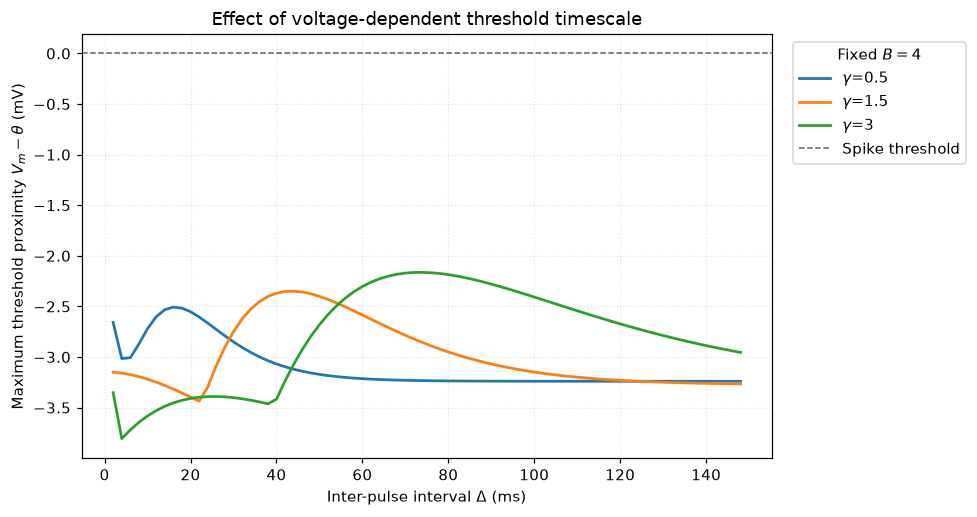

In [9]:
# plot gamma sweep experiment for nestml amat 
plot_sweep_experiment(gamma_sweeps, title="Effect of voltage-dependent threshold timescale", legend_title="Fixed $B=4$")

**Discussion**. Increasing `gamma` shifts the timescale over which the voltage-dependent threshold responds, so the shape and preferred interval of the pulse-pair tuning curve move with `gamma`.


$B$=0: strongest subthreshold response at Δ=2.0 ms (max V_m-θ=-1.106 mV)
$B$=2: strongest subthreshold response at Δ=2.0 ms (max V_m-θ=-2.148 mV)
$B$=4: strongest subthreshold response at Δ=44.0 ms (max V_m-θ=-2.349 mV)


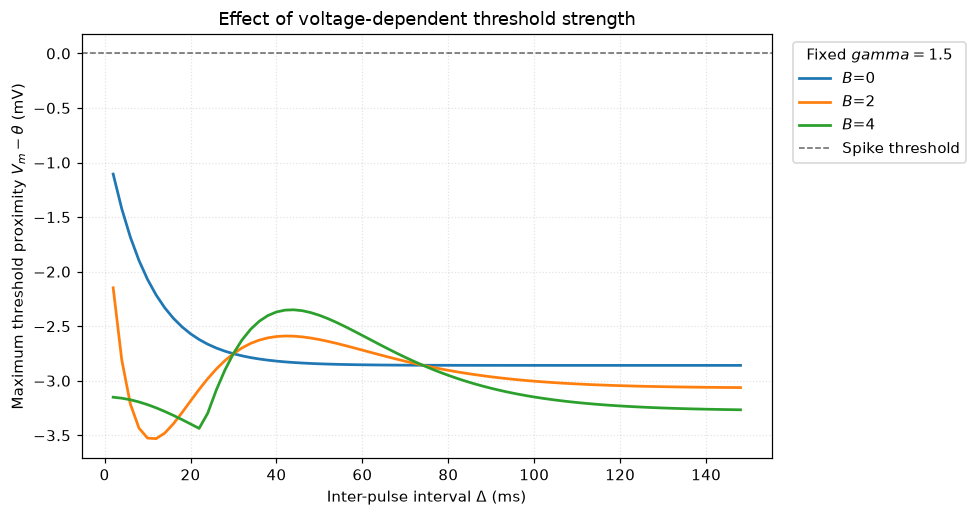

In [11]:
# plot beta gamma sweep for nestml amat 
plot_sweep_experiment(B_sweeps,title="Effect of voltage-dependent threshold strength",legend_title="Fixed $gamma=1.5$")

**Discussion** Increasing `beta` strengthens the voltage-dependent threshold contribution and progressively reshapes the pulse-pair response to a greater amplitude. 

### Integrator control and resonator condition

Here we run two conditions. 
- B=0, disables voltage-dependent threshold contribution
- B=4 activates the voltage-dependent threshold contribution.

Both conditions are fixed with gamma=1.5.

[INFO] Running integrator/resonator baseline...
[INFO] Sweep complete
Integrator: $B=0$, $\gamma=1.5$: strongest subthreshold response at Δ=2.0 ms (max V_m-θ=-1.106 mV)
Resonator: $B=4$, $\gamma=1.5$: strongest subthreshold response at Δ=44.0 ms (max V_m-θ=-2.349 mV)


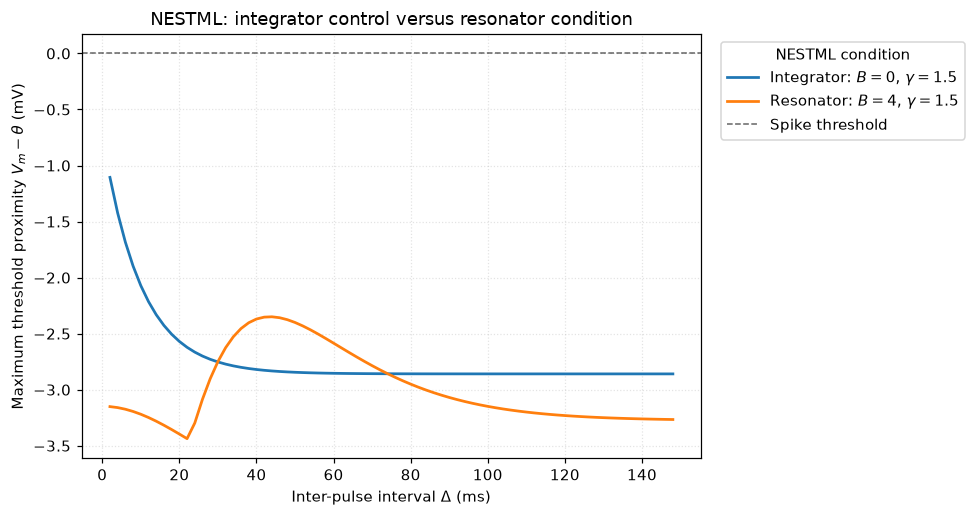

[INFO] Running integrator/resonator baseline...
[INFO] Sweep complete
Integrator: $B=0$, $\gamma=1.5$: strongest subthreshold response at Δ=2.0 ms (max V_m-θ=-1.106 mV)
Resonator: $B=4$, $\gamma=1.5$: strongest subthreshold response at Δ=44.0 ms (max V_m-θ=-2.349 mV)


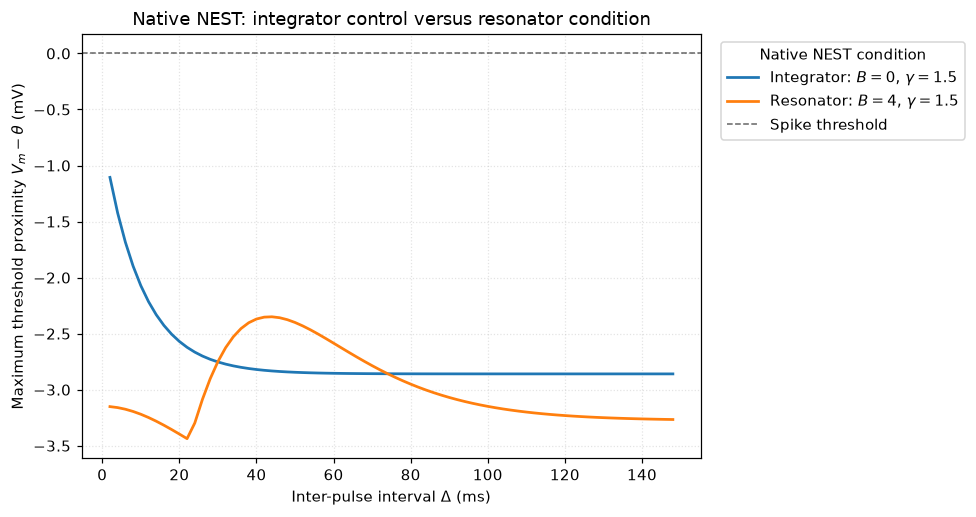

In [12]:
nestml_baseline = delta_sweep(nestml_neuron_model,config,deltas,sweep_type="baseline")
plot_sweep_experiment(nestml_baseline,title="NESTML: integrator control versus resonator condition",legend_title="NESTML condition")

nest_baseline = delta_sweep(nest_model_name,config,deltas,sweep_type="baseline")
plot_sweep_experiment(nest_baseline,title="Native NEST: integrator control versus resonator condition",legend_title="Native NEST condition")


**Conclusion** With (B=0), both NESTML & NEST display the largest response at short inter-pulse intervals, as expected for an integrator-like control. With (B=4), the voltage-dependent threshold reshapes the timing curve and can create a preferred interval, demonstrating resonator-like pulse-pair selectivity before the response is dominated by spiking.

## Brunel Balanced network using AMAT neurons

After NESTML AMAT validation, we can benchmark the model to ensure the model C++ compilation code is running optimially. In these benchmarking experiments, a **brunel balanced network** is utilised. 

A brunel Balanced Network Model is a neural network model that examines how neural stability is maintained through the near-perfect cancellation of massive excitatory and inhibitory currents. By providing a framework for E/I balance, the model can display the emergence of asynchronous and irregular firing behaviours by shifting the E/I balance, connectivity schematic displayed below.  

**Reference** Brunel, *N. Dynamics of Sparsely Connected Networks of Excitatory and Inhibitory Spiking Neurons*. J Comput Neurosci 8, 183–208 (2000). https://doi.org/10.1023/A:1008925309027



In [13]:
def exp_psp_norm(tau_m: float, C_m: float, tau_syn: float) -> float:
    """Peak PSP produced by a unit-amplitude exponential PSC."""
    if np.isclose(tau_m, tau_syn):
        return tau_m / (np.e * C_m)
    t_peak = (tau_m * tau_syn / (tau_m - tau_syn) * np.log(tau_m / tau_syn))
    return (tau_m * tau_syn / (C_m * (tau_m - tau_syn))
            * (np.exp(-t_peak / tau_m) - np.exp(-t_peak / tau_syn)))


def run_balanced_network(model_name: str):
    config = AMATConfig()

    NE = 4 * config.order
    NI = 1 * config.order
    N_neurons = NE + NI

    CE = int(config.epsilon * NE)
    CI = int(config.epsilon * NI)

    N_rec_E = NE  # record from all excitatory neurons
    N_rec_I = NI  # record from all inhibitory neurons

    norm_ex = exp_psp_norm(config.tau_m_ms, config.C_m_pf, config.tau_syn_ex_ms) # calculate the normalisation factor 
    J_ex = config.J_ex / norm_ex 

    delta_V = config.resting_threshold_mv - config.E_L_mv # calculating resting membrane voltage 
    baseline_current = (delta_V * config.C_m_pf) / config.tau_m_ms # calculate the baseline dc current to apply  
    baseline_rate_hz = (1000.0 * baseline_current) / (J_ex * config.tau_syn_ex_ms)
    
    external_rate_hz = config.eta * baseline_rate_hz
    J_in = -config.g * J_ex # setting inhibitory scaling weight 

    nest.ResetKernel() # configuring the nest network 
    nest.resolution = config.resolution
    nest.local_num_threads = 1
    nest.rng_seed = 12345
    nest.print_time = False
    nest.set_verbosity("M_ERROR")

    ensure_model_available(model_name)

    n_processes = nest.NumProcesses()
    n_threads = nest.local_num_threads

    print(f"Balanced Network configuration: {model_name}")
    print(f"Neurons Profile     : {N_neurons} total ({NE} Excitatory, {NI} Inhibitory)")
    print(f"Network Connectivity: CE={CE}, CI={CI}")
    print(f"Excitatory Weight   : {J_ex:.6f} pA")
    print(f"Inhibitory Weight   : {J_in:.6f} pA")
    print(f"External Drive Rate : {external_rate_hz:.3f} Hz/neuron")

    neuron_params = model_parameters(model_name, config)

    start_build = time.perf_counter()

    neurons_ex = nest.Create(model_name, NE, params=neuron_params)
    neurons_in = nest.Create(model_name, NI, params=neuron_params)
    neurons = neurons_ex + neurons_in

    noise = nest.Create("poisson_generator", params={"rate": external_rate_hz})
    spikes_ex = nest.Create("spike_recorder")
    spikes_in = nest.Create("spike_recorder")

    # diagnostic multimeter on a small subsample to check synaptic current delivery
    diag_mm = nest.Create("multimeter", params={
        "record_from": ["V_m", "I_syn_ex", "I_syn_in"], "interval": 1.0})
    nest.Connect(diag_mm, neurons_ex[:5])

    # connect recorders BEFORE simulating so no spikes are lost
    nest.Connect(neurons_ex, spikes_ex)
    nest.Connect(neurons_in, spikes_in)

    # external excitation
    nest.Connect(noise, neurons, syn_spec={"weight": J_ex, "delay": config.delay})

    # recurrent excitation
    nest.Connect(neurons_ex, neurons,
                 conn_spec={"rule": "fixed_indegree", "indegree": CE},
                 syn_spec={"weight": J_ex, "delay": config.delay})

    # recurrent inhibition
    nest.Connect(neurons_in, neurons,
                 conn_spec={"rule": "fixed_indegree", "indegree": CI},
                 syn_spec={"weight": J_in, "delay": config.delay})

    build_time = time.perf_counter() - start_build

    print(f"Starting simulation for {config.balanced_simtime} ms.")

    start_sim = time.perf_counter()   # recording start of simulation time 
    
    nest.Simulate(config.balanced_simtime)
    simulation_time = time.perf_counter() - start_sim   # calculating the simulation time taken 

    events_count_ex = int(spikes_ex.n_events)   # gather exc & inh spikes 
    events_count_in = int(spikes_in.n_events)

    events_ex_dict = nest.GetStatus(spikes_ex, "events")[0]
    events_in_dict = nest.GetStatus(spikes_in, "events")[0]
 
    rate_ex = (events_count_ex * 1000.0 / (config.balanced_simtime * N_rec_E)) if N_rec_E > 0 else 0.0   # calculate the rate hz from inh and exc 
    rate_in = (events_count_in * 1000.0 / (config.balanced_simtime * N_rec_I)) if N_rec_I > 0 else 0.0

    # diagnostic: did synaptic current ever move at all?
    diag_events = nest.GetStatus(diag_mm, "events")[0]
    if len(diag_events.get("I_syn_ex", [])) > 0:
        print(f"[diag] I_syn_ex range: {diag_events['I_syn_ex'].min():.4f} to {diag_events['I_syn_ex'].max():.4f}")
        print(f"[diag] I_syn_in range: {diag_events['I_syn_in'].min():.4f} to {diag_events['I_syn_in'].max():.4f}")
        print(f"[diag] V_m range: {diag_events['V_m'].min():.4f} to {diag_events['V_m'].max():.4f}")

    scaling_results = {
        "n_threads": int(n_threads),
        "mpi_processes": int(n_processes),
        "total_cores": int(n_processes * n_threads),
        "build_time_s": float(build_time),
        "simulation_time_s": float(simulation_time),
        "total_wall_clock_s": float(build_time + simulation_time),
        "total_neurons": int(N_neurons),
        "total_synapses": int(N_neurons * (CE + CI)),
        "n_recorded_ex": int(N_rec_E),
        "n_recorded_in": int(N_rec_I),
        "events_ex_dict": events_ex_dict,
        "events_in_dict": events_in_dict,
        "total_spikes_captured": int(events_count_ex + events_count_in),
        "exc_rate_hz": float(rate_ex),
        "inh_rate_hz": float(rate_in)}

    print(f"Scaling results: {model_name}")
    for k, v in scaling_results.items():
        if k not in {"events_ex_dict", "events_in_dict"}:
            print(f"  {k:<22}: {v}")

    return scaling_results


nestml_balanced_df = run_balanced_network(nestml_neuron_model)
nest_balanced_df = run_balanced_network(nest_model_name)

Balanced Network configuration: amat_neuron_nestml
Neurons Profile     : 1250 total (1000 Excitatory, 250 Inhibitory)
Network Connectivity: CE=100, CI=25
Excitatory Weight   : 38.746490 pA
Inhibitory Weight   : -154.985960 pA
External Drive Rate : 2580.879 Hz/neuron
Starting simulation for 1000.0 ms.
[diag] I_syn_ex range: 0.0000 to 450.0942
[diag] I_syn_in range: -639.3192 to -0.0000
[diag] V_m range: -73.3935 to -60.7805
Scaling results: amat_neuron_nestml
  n_threads             : 1
  mpi_processes         : 1
  total_cores           : 1
  build_time_s          : 0.058075024047866464
  simulation_time_s     : 0.6856703241355717
  total_wall_clock_s    : 0.7437453481834382
  total_neurons         : 1250
  total_synapses        : 156250
  n_recorded_ex         : 1000
  n_recorded_in         : 250
  total_spikes_captured : 6618
  exc_rate_hz           : 5.315
  inh_rate_hz           : 5.212
Balanced Network configuration: amat2_psc_exp
Neurons Profile     : 1250 total (1000 Excitatory,

**Discussion** 

The firing rates and captured events counts provides an activity sanity-check, since we are simulating the exact same Brunel model `exc_rate` and`inh_rate` should be the exact same (0-10 Hz). `network_build_time_s` measures construction of nodes and connections after the NESTML extension has already been generated and loaded, whereas `simulation_time_s` measures the actual network simulation, NEST is notably faster in both. 


## Plotting network activity and interspike interval profiles of NEST and NESTML 

After running brunel balanced network simulations for `amat_neuron_nestml` and `amat2_psc_exp`, we can visualise the network dynamics.

The raster plots show when individual excitatory and inhibitory neurons fire, while the lower panel summarises the same events as a population firing rate. The interspike-interval (ISI) distribution then compares the temporal structure of repeated firing between the native NEST and generated NESTML implementations.

In [14]:
def raster_profile(model_type: str,ev_ex: dict,ev_in: dict,n_recorded_total: int):
    
    config = AMATConfig()
    t_ex, s_ex = ev_ex["times"], ev_ex["senders"] # exc spike times and sender
    t_in, s_in = ev_in["times"], ev_in["senders"] # inh spike times and sender 

    # format raster plot 
    fig, (ax_raster, ax_rate) = plt.subplots(2,1,figsize=(10, 6),sharex=True,gridspec_kw={"height_ratios": [2.5, 1]})
    ax_raster.plot(t_ex,s_ex,".",color="tab:blue",markersize=2,label="Excitatory",alpha=0.5)
    ax_raster.plot(t_in,s_in,".",color="tab:red",markersize=2,label="Inhibitory",alpha=0.5)
    ax_raster.set_ylabel("Neuron ID")
    ax_raster.set_title(
        f"{model_type} balanced network "
        f"(N_exc={config.order * 4}, N_inh={config.order}, "
    )
    ax_raster.legend(loc="upper right", markerscale=4)
    ax_raster.grid(True, linestyle=":", alpha=0.4)

    all_spikes = np.concatenate([t_ex, t_in])
    bin_width_ms = 1.0
    bins = np.arange(0, config.balanced_simtime + bin_width_ms,bin_width_ms)

    ax_rate.set_title(f"{model_type} population firing rate")
    if len(all_spikes) > 0 and n_recorded_total > 0:
        counts, edges = np.histogram(all_spikes, bins=bins)
        population_hz = (counts * 1000.0 / (bin_width_ms * n_recorded_total))
        ax_rate.plot(edges[:-1], population_hz, color="black")
    else:
        ax_rate.text(0.5, 0.5, "No spikes recorded", ha="center", va="center", transform=ax_rate.transAxes)

    ax_rate.set_xlabel("Time (ms)")
    ax_rate.set_ylabel("Rate (Hz)")
    ax_rate.set_xlim(0, config.balanced_simtime)
    ax_rate.grid(True, linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()


def isi_profile(ev_ex_nestml: dict, ev_in_nestml: dict, ev_ex_nest: dict, ev_in_nest: dict):
    
    bins = np.arange(0, 164, 4)
    variants = [
        ("NESTML", ev_ex_nestml, ev_in_nestml, "tab:orange"),
        ("NEST", ev_ex_nest, ev_in_nest, "tab:blue")]

    for label, ex, inh, color in variants:
        isis = []
        for data in (ex, inh):
            for neuron in np.unique(data["senders"]):
                spikes = np.sort(
                    data["times"][data["senders"] == neuron])
                if len(spikes) > 1:
                    isis.extend(np.diff(spikes))
        if isis:
            isis = np.asarray(isis)
            weights = np.ones_like(isis) / len(isis) * 100.0
            plt.hist(isis, bins=bins, weights=weights, histtype="step", linewidth=2, color=color, label=label)

    plt.xlabel("ISI (ms)")
    plt.ylabel("Frequency of occurrence (%)")
    plt.title("Interspike-interval profile")
    plt.xlim(0, 160)
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


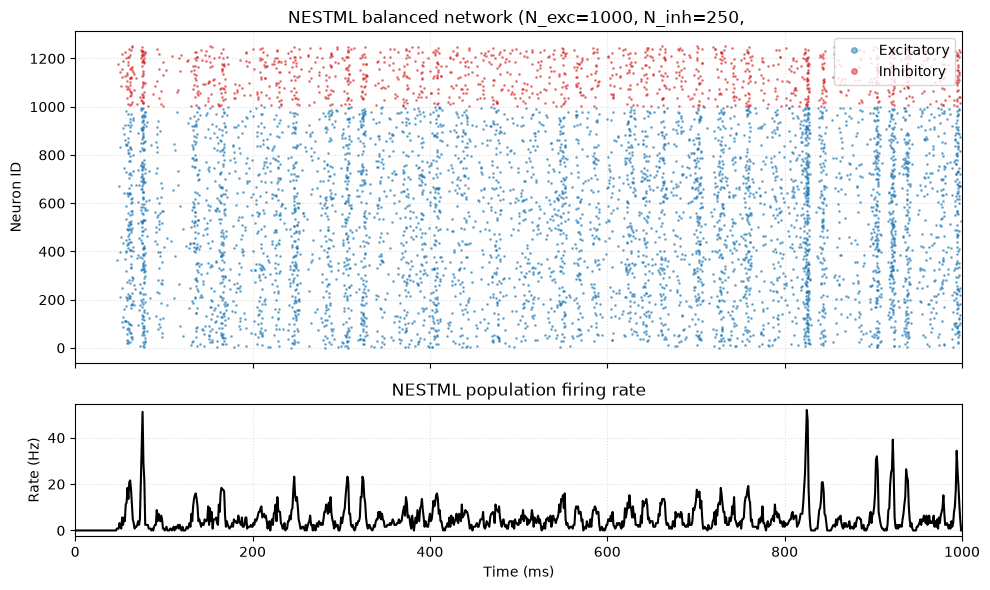

In [15]:
raster_profile(
    model_type="NESTML",
    ev_ex=nestml_balanced_df["events_ex_dict"],
    ev_in=nestml_balanced_df["events_in_dict"],
    n_recorded_total=(nestml_balanced_df["n_recorded_ex"] + nestml_balanced_df["n_recorded_in"]))


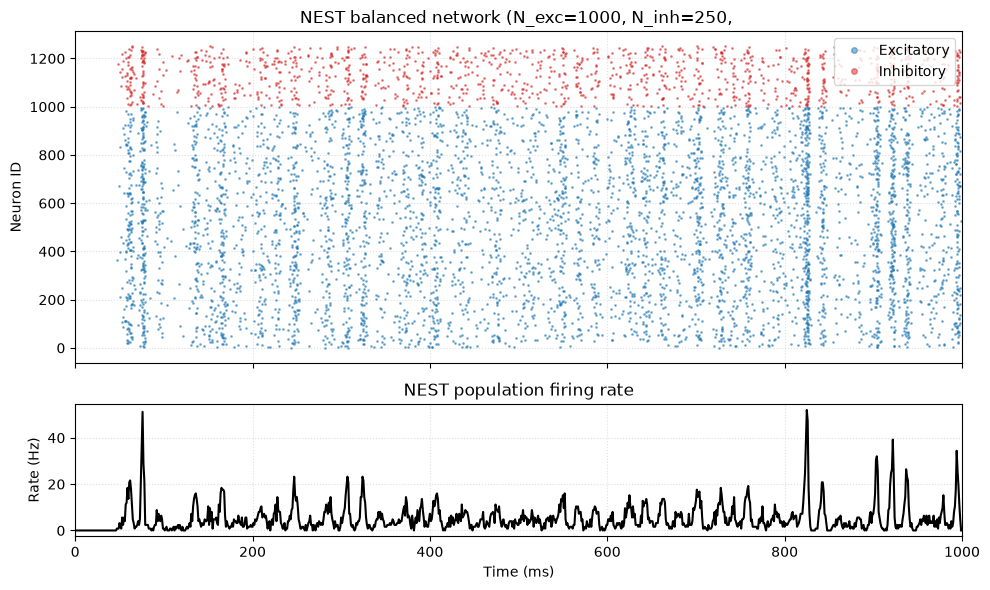

In [16]:
raster_profile(
    model_type="NEST",
    ev_ex=nest_balanced_df["events_ex_dict"],
    ev_in=nest_balanced_df["events_in_dict"],
    n_recorded_total=(nest_balanced_df["n_recorded_ex"] + nest_balanced_df["n_recorded_in"]))


**Discussion**. Both NEST and NESTML display low-frequency, highly irregular rates seen in the sparse scattering of dots for each neuronal ID in the raster plot. However, the network also exhibits strong, collective oscillations this is happens due to a wave of recurrent excitatory synapses activated together leading to a massive wave of firing. This wave is then rapidly shut down a few milliseconds later by delayed, powerful feedback inhibition, leaving an isolated global spike in the population rate.

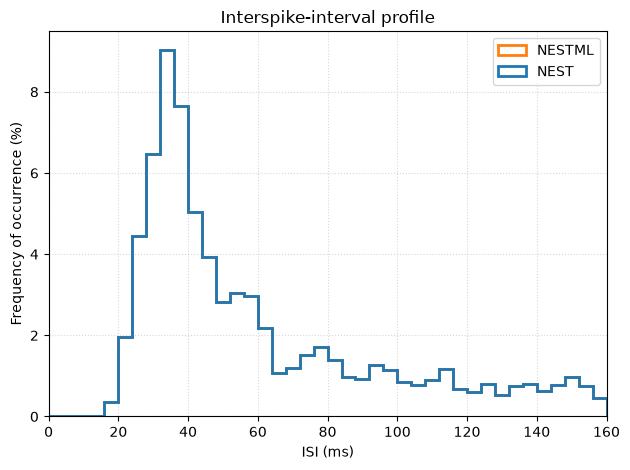

In [17]:
isi_profile(
    ev_ex_nestml=nestml_balanced_df["events_ex_dict"], # plotting nestml dict for spike times 
    ev_in_nestml=nestml_balanced_df["events_in_dict"],
    ev_ex_nest=nest_balanced_df["events_ex_dict"], # plotting nest dict for spike times
    ev_in_nest=nest_balanced_df["events_in_dict"])

**Discussion**. Overlapping ISI profiles indicate that the temporal statistics of repeated firing are preserved between NESTML and the native NEST reference. This complements the raster comparison by testing spike timing structure rather than only total event counts or mean firing rates.

### High-performance computing benchmark


The examples above in the notebook are intentionally small enough to run interactively on your local computer.

To examine computational scaling, the same AMAT network can be benchmarked separately on an HPC system and the resulting figures included here as precomputed results; the tutorial itself should not submit scheduler jobs.

In strong scaling, the network problem size is fixed while the number of compute resources increases, so useful scaling appears as a reduction in wall-clock time. In weak scaling, the network size grows with the available compute resources, so good scaling appears as approximately constant wall-clock time per simulation.

For a reproducible comparison, each implementation should use the same biological simulation time, network construction, connectivity rule, parameter set, and activity-validation checks. Record the hardware, NEST/NESTML versions, MPI processes and threads, number of repetitions, and report the timing variability alongside the mean or median.

<img src="images/performance_benchmark.png" width="1050" height="600">

**Discussion** These benchmark scaling results evaluate the performance differences between NEST and NESTML across both strong and weak scaling benchmarks on a high-performance computing (HPC) system. In both strong and weak scaling scenarios, NEST consistently achieves the lowest overall wall clock time. The NESTML overhead causes it to run up to approximately 1.33× slower than native NEST. This overhead is expected because NESTML dynamically generates C++ code from a domain-specific language, which can miss certain hand-optimized compiler or structural micro-optimizations embedded directly within native NEST's core codebase.

Acknowledgements
----------------

Developed by: Angus Gray

My thanks to the organisers of the JSC Guest Student Programme 2026 and to my supervisor Charl Linssen for his guidance throughout this project. 

This software was developed in part or in whole in the Human Brain Project, funded from the European Union’s Horizon 2020 Framework Programme for Research and Innovation under Specific Grant Agreements No. 720270 and No. 785907 (Human Brain Project SGA1 and SGA2).

License
-------

This notebook (and associated files) is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 2 of the License, or (at your option) any later version.

This notebook (and associated files) is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.